In [1]:
import random
import scipy.stats as sps
import itertools as it
import copy
import os
import concurrent
import math
import heapq
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
class Client:
    def __init__(self, place, idx):
        self.place = place
        self.idx = idx
        self.distances = dict()  
        self.tight_edges = set()
        self.tight_events = dict()
        self.connected = None

class Facility:
    def __init__(self, place, cost, idx):
        self.place = place
        self.idx = idx
        self.cost = cost       
        self.open_time: float = None   
        self.tight_edges = set() 
        self.open_event: Event = None
        self.witness : int = None
        self.witness_time : float = None



def dist(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2), ord=2)

class Event:
    def __init__(self, event_type, payload):
        self.type = event_type # tight или open
        self.payload = payload # (i, j) или (j, k, remain_time, timestamp) - k - количество активных

event_heap = []                         
entry_finder = {}               
REMOVED = '<removed-task>'      
counter = it.count()     

# код украден с документации питона
def add_task(task, priority=0):
    'Add a new task or update the priority of an existing task'
    if task in entry_finder:
        remove_task(task)
    count = next(counter)
    entry = [priority, count, task]
    entry_finder[task] = entry
    heapq.heappush(event_heap, entry)

def remove_task(task):
    'Mark an existing task as REMOVED.  Raise KeyError if not found.'
    if task in entry_finder:
        entry = entry_finder.pop(task)
        entry[-1] = REMOVED

def pop_task():
    'Remove and return the lowest priority task. Raise KeyError if empty.'
    while event_heap:
        priority, count, task = heapq.heappop(event_heap)
        if task is not REMOVED:
            del entry_finder[task]
            return priority, task
    raise KeyError('pop from an empty priority queue')

def calculate_min_cool_way(clients, facilities, facilities_count):
    possible_variants = it.product(range(2), repeat = facilities_count)
    total_cost = 1e10000
    min_facs = []
    for i in possible_variants:
        possible_cost = 0
        unique_facilities = [j for j in range(len(i)) if i[j] == 1]
        for j in unique_facilities:
            possible_cost += facilities[j].cost
        for j in clients:
            client_min = 1e10000
            for z in unique_facilities:
                client_min = min(client_min, clients[j].distances[z])
            possible_cost += client_min
        if total_cost > possible_cost:
            min_facs = copy.copy(unique_facilities)
            total_cost = possible_cost
    return total_cost, min_facs

In [3]:
df = random.randint(1, 100)
rv = sps.uniform(0, 1000)
clients_count = random.randint(1, 10000)
facilities_count = random.randint(15, 15)

In [4]:

def one_calc(rv, clients_count, facilities_count, dims):
    global event_heap                         
    global entry_finder
    event_heap = []   
    entry_finder = {}   
    clients = {i: Client(rv.rvs([dims]), i) for i in range(clients_count)}
    facilities = {j: Facility(rv.rvs([dims]), float(rv.rvs(1)[0]), j) for j in range(facilities_count)}

    for j, fac in facilities.items():
        for i, cl in clients.items():
            c = dist(fac.place, cl.place)
            fac.distances = fac.distances if hasattr(fac, 'distances') else dict()
            fac.distances[i] = c
            cl.distances[j] = c


    # init
    for j, fac in facilities.items():
        for i, cl in clients.items():
            c = dist(fac.place, cl.place)
            add_task(Event("tight", (i, j)), c)

    event = None
    curr_time = 0
    while True:
        try:
            end_time, event = pop_task()
        except:
            break
        
        curr_time = end_time
        if event.type == "tight":
            i, j = event.payload
            if clients[i].connected is not None:
                continue

            clients[i].tight_edges.add(j)
            facilities[j].tight_edges.add(i)
            if facilities[j].open_time is not None:
                clients[i].connected = j
                continue

            open_event = facilities[j].open_event
            if open_event is not None:
                j2, k, remain_time, timestamp = open_event.payload
                remain_time = remain_time - (timestamp - curr_time) * k
                open_event.payload = (j2, k + 1, remain_time, curr_time) 
                add_task(event, curr_time + remain_time / (k + 1))
            else:
                new_event = Event("open", (j, 1, facilities[j].cost, curr_time))
                facilities[j].open_event = new_event
                clients[i].tight_events[j] = new_event
                add_task(new_event, curr_time + facilities[j].cost)

        if event.type == "open":
            j, k, remain_time, timestamp = event.payload
            if k == 0:
                raise("k == 0")
            for client in facilities[j].tight_edges:
                if clients[client].connected is not None:
                    continue
                clients[client].connected = j

                for tight_edge in clients[client].tight_edges:
                    if tight_edge == j:
                        continue

                    edit_event = facilities[tight_edge].open_event
                    j2, k, remain_time, timestamp = edit_event.payload
                    remain_time = remain_time - (timestamp - curr_time) * k
                    edit_event.payload = (j2, k - 1, remain_time, curr_time)
                    if k - 1 == 0:
                        remove_task(edit_event)
                    else:
                        add_task(event, curr_time + remain_time / (k - 1))

            facilities[j].open_time = curr_time

    # for i, cl in clients.items():
    #     print(f"i: {i}, con: {cl.connected}, tight: {cl.tight_edges}")

    F_t = []
    for j, fc in facilities.items():
        if fc.open_time is not None:
            F_t.append([fc.open_time, j, fc])

    F_t.sort(key=lambda x: x[0])
    # print([fc.open_time for j, fc in facilities.items()])

    fc : Facility = None
    H = set()
    for item in F_t:
        _, j, fc = item
        for tight_to_client in fc.tight_edges:
            common = H.intersection(clients[tight_to_client].tight_edges)
            if len(common) > 0:
                for j2 in common:
                    if fc.witness_time is None or facilities[j2].open_time < fc.witness_time:
                        fc.witness_time = facilities[j2].open_time
                        fc.witness = j2

        if fc.witness is None:
            H.add(j)

    j = None
    for i, cl in clients.items():
        intersect = H.intersection(cl.tight_edges)
        if len(intersect) > 0:
            cl.connected = intersect.pop()
            continue

        while True: 
            j = cl.tight_edges.pop()
            if facilities[j].open_time is not None:
                break
        cl.connected = facilities[j].witness

    # print()
    # print(H)
    # print()


    # for i, cl in clients.items():
    #     print(f"i: {i}, con: {cl.connected}, tight: {cl.tight_edges}")

    total_cost = 0
    powered = set()
    for i, cl in clients.items():
        total_cost += dist(cl.place, facilities[cl.connected].place)
        powered.add(cl.connected)

    for j in powered:
        total_cost += facilities[j].cost

    total_cost2, min_facs = calculate_min_cool_way(clients, facilities, facilities_count)
    # print(total_cost2, min_facs)
    # print(total_cost / total_cost2)

    return total_cost, total_cost2



In [5]:
results = []

def calc1():
    results_local = []
    for i in range(25):
        if i%5 == 0:
            print(1, i)
        rv = sps.uniform(0, 1000)
        clients_count = random.randint(1, 1000)
        facilities_count = random.randint(15, 15)
        total_cost_approx, total_cost_precise = one_calc(rv, clients_count, facilities_count, 4)
        results_local.append((clients_count, facilities_count, total_cost_approx, total_cost_precise))
    return results_local

def calc2():
    results_local = []
    for i in range(100):
        if i%25 == 0:
            print(2, i)
        rv = sps.uniform(0, 10000)
        clients_count = random.randint(1, 10000)
        facilities_count = random.randint(10, 10)
        total_cost_approx, total_cost_precise = one_calc(rv, clients_count, facilities_count, 4)
        results_local.append((clients_count, facilities_count, total_cost_approx, total_cost_precise))
    return results_local

def calc3():
    results_local = []
    for i in range(100):
        if i%25 == 0:
            print(3, i)
        rv = sps.uniform(0, 10000)
        clients_count = random.randint(1, 10)
        facilities_count = random.randint(20, 20)
        total_cost_approx, total_cost_precise = one_calc(rv, clients_count, facilities_count, 4)
        results_local.append((clients_count, facilities_count, total_cost_approx, total_cost_precise))
    return results_local

def calc4():
    results_local = []
    for i in range(100):
        if i%25 == 0:
            print(4, i)
        rv = sps.uniform(0, 10000)
        clients_count = random.randint(1, 10000)
        facilities_count = random.randint(1, 5)
        total_cost_approx, total_cost_precise = one_calc(rv, clients_count, facilities_count, 4)
        results_local.append((clients_count, facilities_count, total_cost_approx, total_cost_precise))
    return results_local

with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
    tasks = [executor.submit(calc1), executor.submit(calc2), executor.submit(calc3), executor.submit(calc4)]
    for future in concurrent.futures.as_completed(tasks):
        results_local = future.result()
        results += results_local


1234    0000



4 25
4 50
4 75
1 5
2 25
1 10
3 25
1 15
2 50
1 20
2 75
3 50
3 75


     clients  facilities   approx_cost     true_cost
0       7609           5  4.558215e+07  4.059867e+07
1        771           5  4.654364e+06  3.590958e+06
2       2441           5  1.604269e+07  1.136514e+07
3       7288           4  4.711532e+07  4.144071e+07
4       3269           5  2.582393e+07  1.673110e+07
..       ...         ...           ...           ...
320        3          20  1.789259e+04  1.789259e+04
321        6          20  4.253618e+04  3.258698e+04
322        4          20  2.527615e+04  2.527615e+04
323        1          20  6.056411e+03  6.056411e+03
324        7          20  4.957838e+04  3.950864e+04

[325 rows x 4 columns]
     clients  facilities   approx_cost     true_cost      rate
0       7609           5  4.558215e+07  4.059867e+07  1.122750
1        771           5  4.654364e+06  3.590958e+06  1.296134
2       2441           5  1.604269e+07  1.136514e+07  1.411570
3       7288           4  4.711532e+07  4.144071e+07  1.136933
4       3269           5 

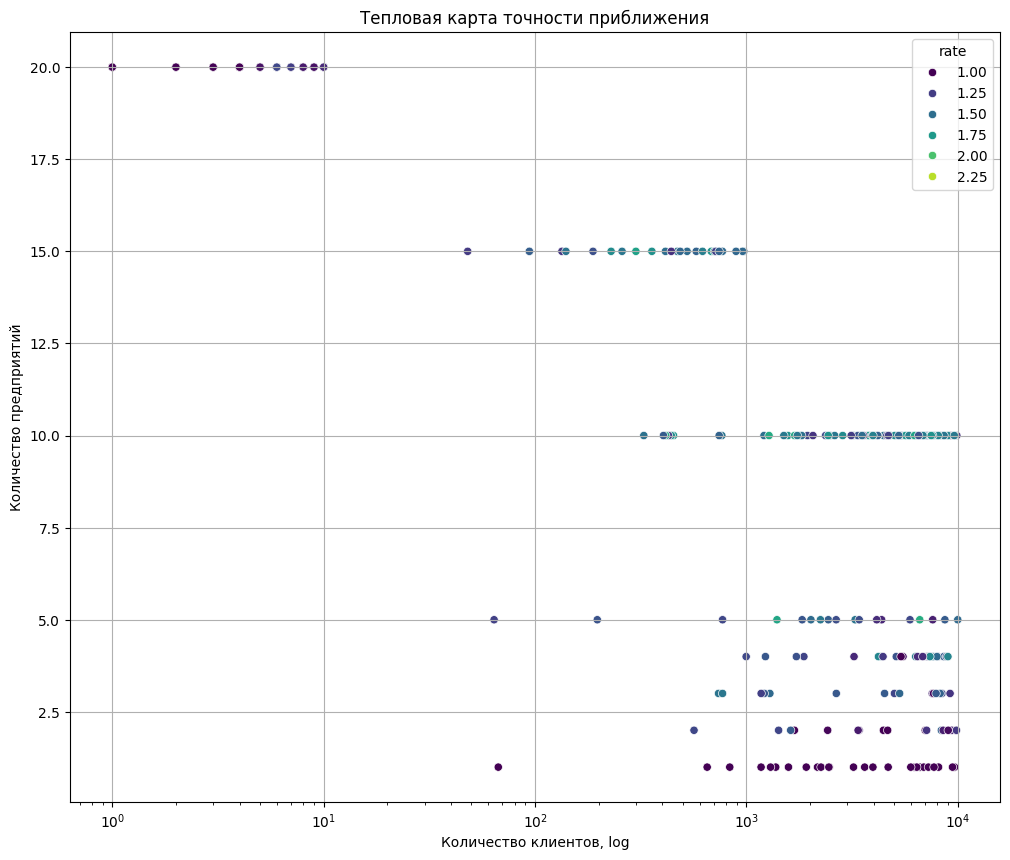

In [26]:
data = results
# for key, value in results.items():
#     results_copy[key] = list(value) + [value[0] / value[1]]
#     data.append(list(key) + [value[0] / value[1]])


df = pd.DataFrame(data, columns=['clients', 'facilities', 'approx_cost', 'true_cost'])
print(df)
df['rate'] = df['approx_cost'] / df['true_cost']
print(df)

plt.figure(figsize=(12, 10))
plt.title("Тепловая карта точности приближения")
plt.ylabel("Количество предприятий")
plt.xlabel("Количество клиентов, log")
plt.xscale("log")
sns.scatterplot(
    data=df,
    x='clients',
    y='facilities',
    hue='rate',
    palette='viridis'
)
plt.grid()
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

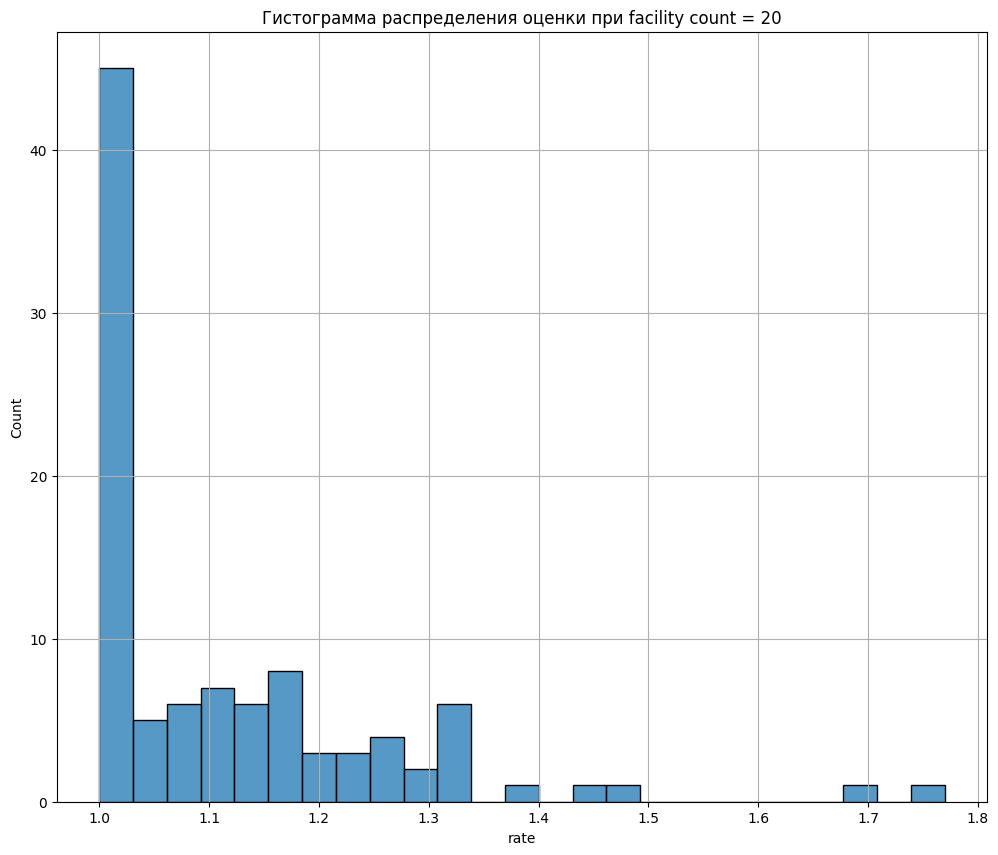

In [27]:
plt.figure(figsize=(12, 10))
plt.title("Гистограмма распределения оценки при facility count = 20")
sns.histplot(
    df[df["facilities"] == 20]["rate"],
    stat="count",
    bins=25
)
plt.grid()
plt.savefig("fc20.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

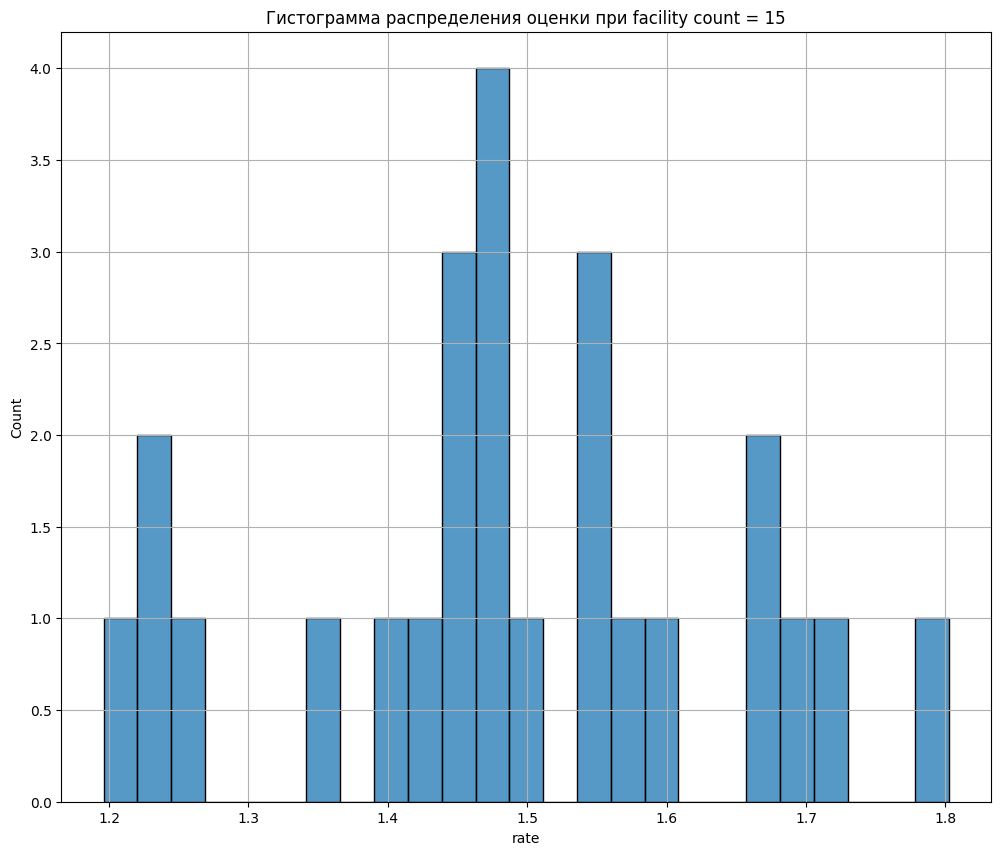

In [28]:
plt.figure(figsize=(12, 10))
plt.title("Гистограмма распределения оценки при facility count = 15")
sns.histplot(
    df[df["facilities"] == 15]["rate"],
    stat="count",
    bins=25
)
plt.grid()
plt.savefig("fc15.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

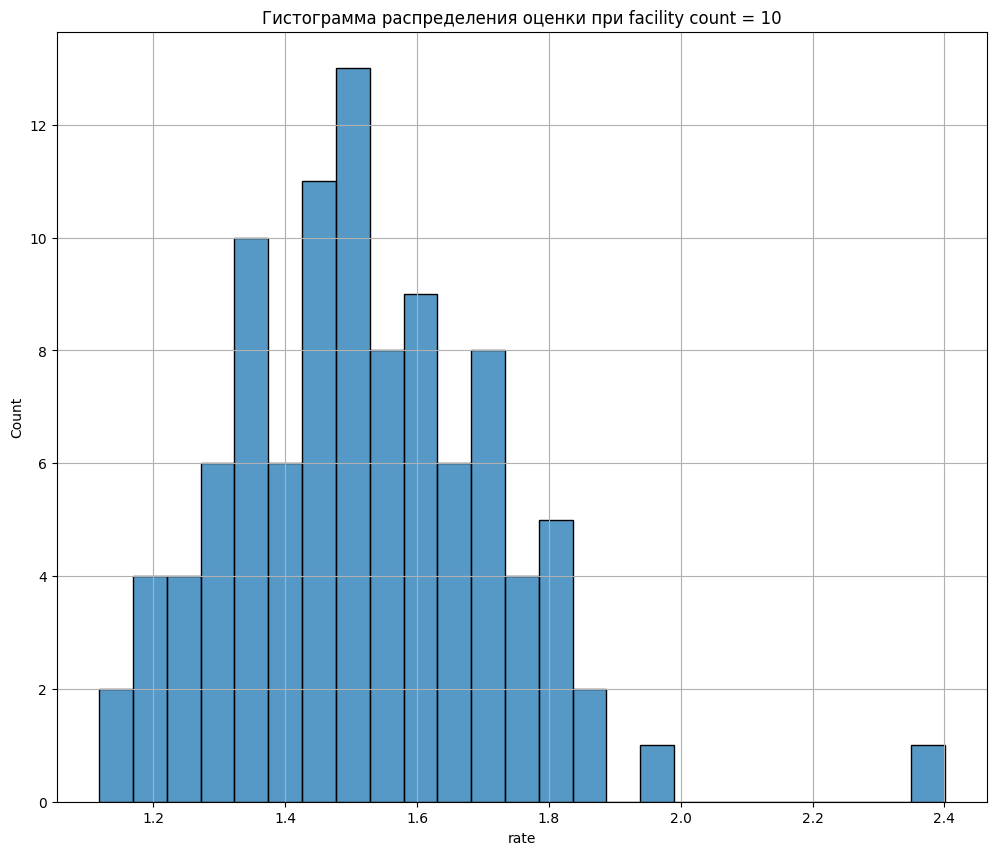

In [29]:
plt.figure(figsize=(12, 10))
plt.title("Гистограмма распределения оценки при facility count = 10")
sns.histplot(
    df[df["facilities"] == 10]["rate"],
    stat="count",
    bins=25
)
plt.grid()
plt.savefig("fc10.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

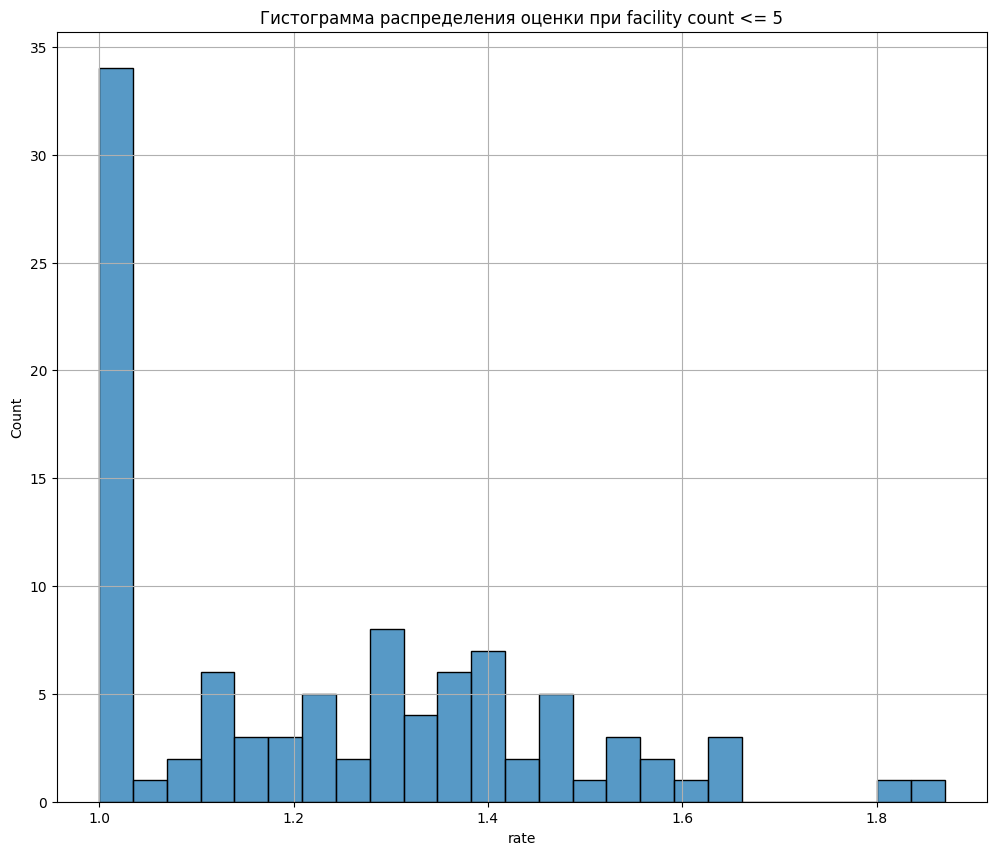

In [30]:
plt.figure(figsize=(12, 10))
plt.title("Гистограмма распределения оценки при facility count <= 5")
sns.histplot(
    df[df["facilities"] <= 5]["rate"],
    stat="count",
    bins=25
)
plt.grid()
plt.savefig("fc5.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()